In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Notebooks") # changed to path folder with data

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

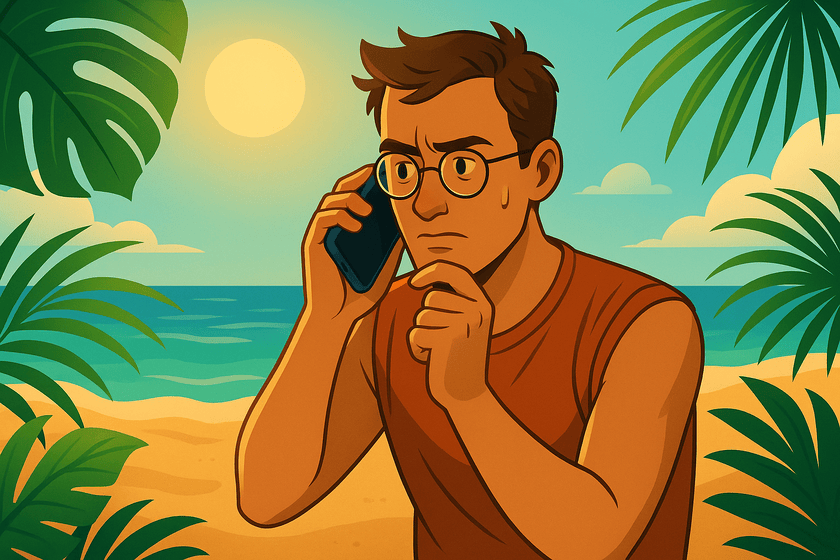

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

Zmienną przewidywaną jest Survived - zmienna binarna (0 - zginął, 1 - przeżył).

In [4]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


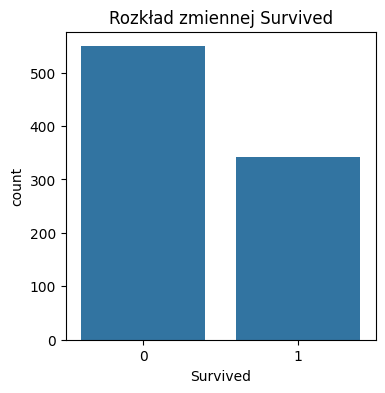

In [5]:
plt.figure(figsize=(4, 4))
sns.countplot(data=titanic_df, x='Survived')
plt.title('Rozkład zmiennej Survived')
plt.show()

W zbiorze zginęło ok. 62% pasażerów, a przeżyło ok. 38%. Klasy nie są idealnie zbalansowane, ale nie jest to duża różnica.

### 1. Struktura danych i typy kolumn

In [7]:
titanic_df.info()
titanic_df.isna().sum().sort_values(ascending=False)
titanic_df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,793.0,NaN,NaN,NaN,33.123938,51.578312,0.0,7.925,14.5,31.275,512.3292
Cabin,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Zbiór ma 891 wierszy, więc braki danych można zauważyć dla:

*   Age - 177 braków
*   Cabin - 687 braków
*   Embarked - 2 braki
*   Fare - 98 braków

Pozostałe kolumny są kompletne.

Kolumny Name i Ticket same w sobie nie są przydatne jako cechy, ale z Name trzeba wyciągnąć tytuł grzecznościowy, a Cabin będzie potrzebne do stworzenia dwóch nowych cech.

In [8]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*([^.]*)\.')

title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
titanic_df['Title'] = titanic_df['Title'].replace(title_mapping)

rare_titles = titanic_df['Title'].value_counts()[titanic_df['Title'].value_counts() < 10].index
titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Rare')
titanic_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


Z kolumny 'Name' wyodrębniono kolumnę 'Title' czyli tytuły grzecznościowe oraz wyodrębniono te które występują mniej niż 10 razy i zgrupowano w Rare. Najwięcej wystopień to Mr.

In [9]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

In [10]:
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df['Deck'] = titanic_df['Cabin'].str[0].fillna('U')

In [17]:
def fill_missing_with_group_median(df, target_col, group_cols):
    df[target_col] = df.groupby(group_cols, observed=True)[target_col].transform(
        lambda x: x.fillna(x.median())
    )
    df[target_col] = df[target_col].fillna(df[target_col].median())
    return df

titanic_df = fill_missing_with_group_median(titanic_df, 'Age', ['Title', 'Pclass'])

if titanic_df['Embarked'].isna().any():
    titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

if titanic_df['Fare'].isna().any():
    titanic_df = fill_missing_with_group_median(titanic_df, 'Fare', ['Pclass'])

titanic_df = titanic_df.drop(columns=['Cabin', 'Name', 'Ticket'])
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0
FamilySize,0


Po uzupełnieniu Age (mediana Title + Pclass), Fare (mediana Pclass), Embarked (dominanta) i usunięciu Name, Ticket, Cabin (ich informacja jest już w Title, FamilySize/IsAlone, HasCabin/Deck), zbiór nie zawiera braków.

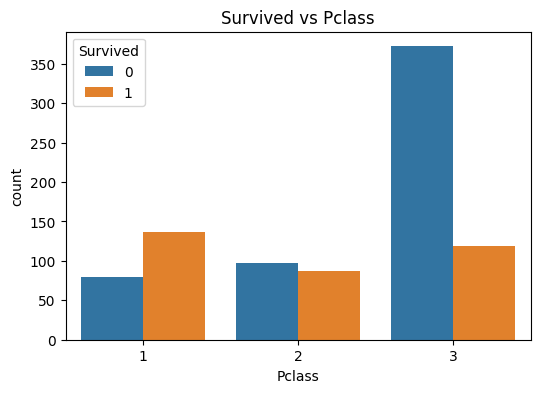

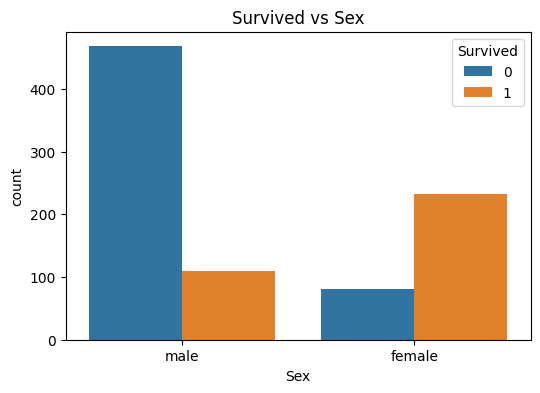

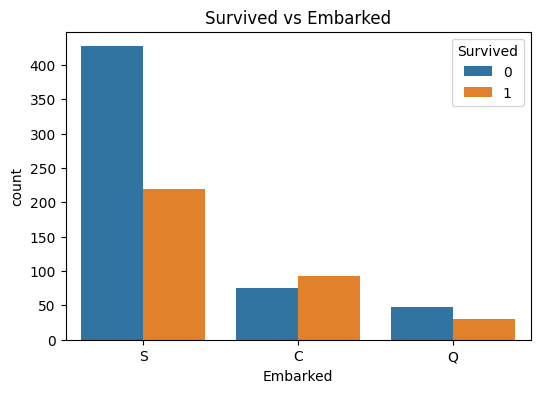

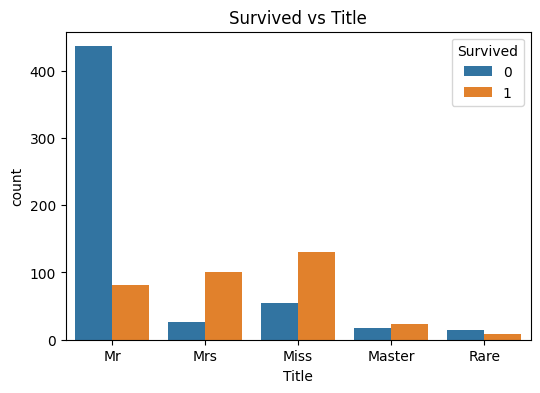

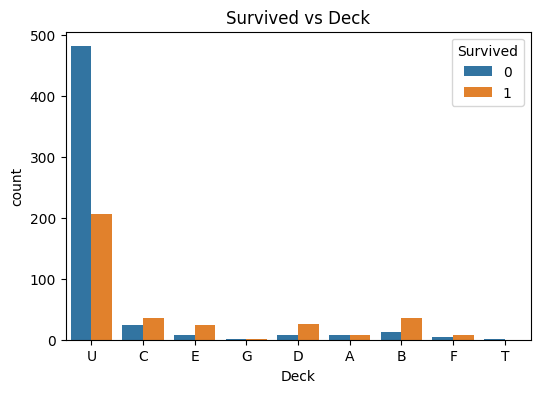

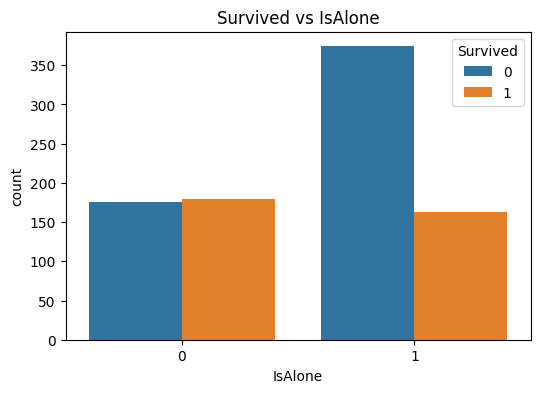

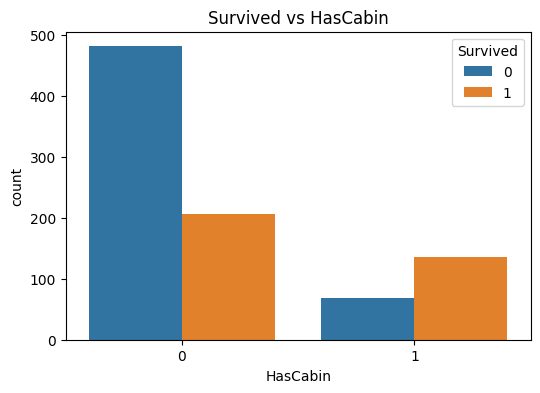

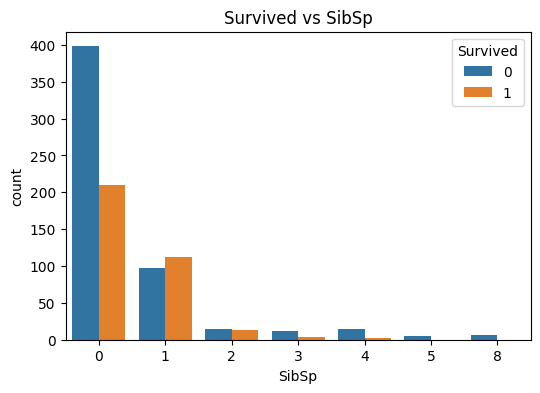

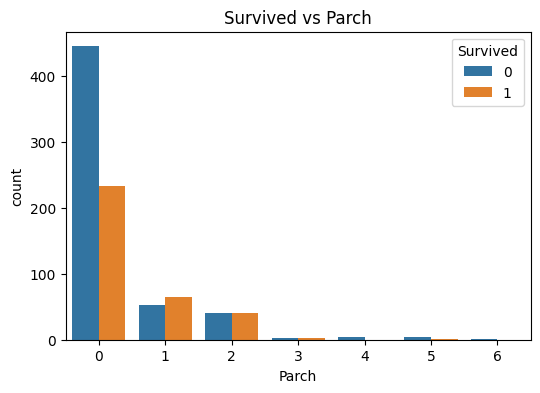

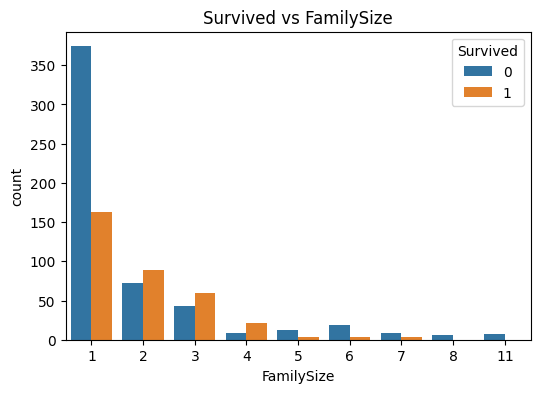

In [12]:
def plot_categorical_vs_survived(df, col):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='Survived')
    plt.title(f'Survived vs {col}')
    plt.show()

def plot_numeric_by_survived(df, col):
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue='Survived', common_norm=False)
    plt.title(f'Rozkład {col} wg Survived')
    plt.show()

categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck',
                     'IsAlone', 'HasCabin', 'SibSp', 'Parch', 'FamilySize']
for col in categorical_cols:
    plot_categorical_vs_survived(titanic_df, col)

Klasa podróży i płeć to najsilniejsze widoczne czynniki: pasażerowie I klasy przeżywali najczęściej, kobiety zdecydowanie częściej niż mężczyźni. Embarked=C (Cherbourg) ma wyższy odsetek ocalałych niż S. Deck: najliczniejsza grupa to U (nieznany pokład) i ma niższy odsetek ocalałych niż grupy ze znanym pokładem (HasCabin jest sensowną cechą). IsAlone: samotni przeżywali rzadziej. SibSp/Parch/FamilySize: najlepsze szanse mieli pasażerowie z małą rodziną (1 - 3 osoby).

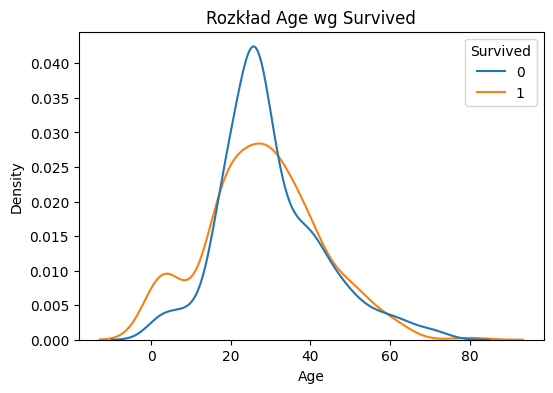

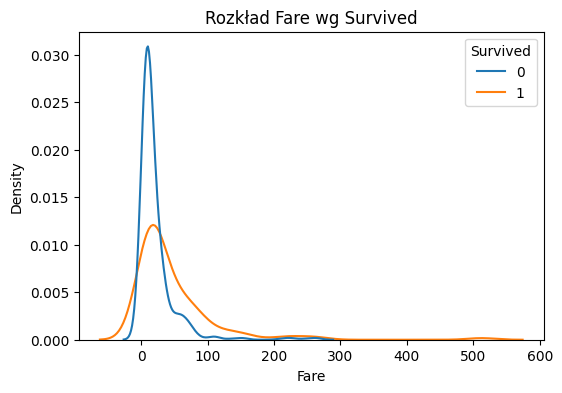

In [13]:
for col in ['Age', 'Fare']:
    plot_numeric_by_survived(titanic_df, col)

*   Age - rozkłady ocalałych i nieocalałych są zbliżone, ale wśród dzieci widać wyraźną przewagę ocalałych.
*   Fare - ocaleni płacili wyższe ceny.

Age: 22 outlierów (IQR)
Fare: 105 outlierów (IQR)
SibSp: 46 outlierów (IQR)
Parch: 213 outlierów (IQR)
FamilySize: 91 outlierów (IQR)


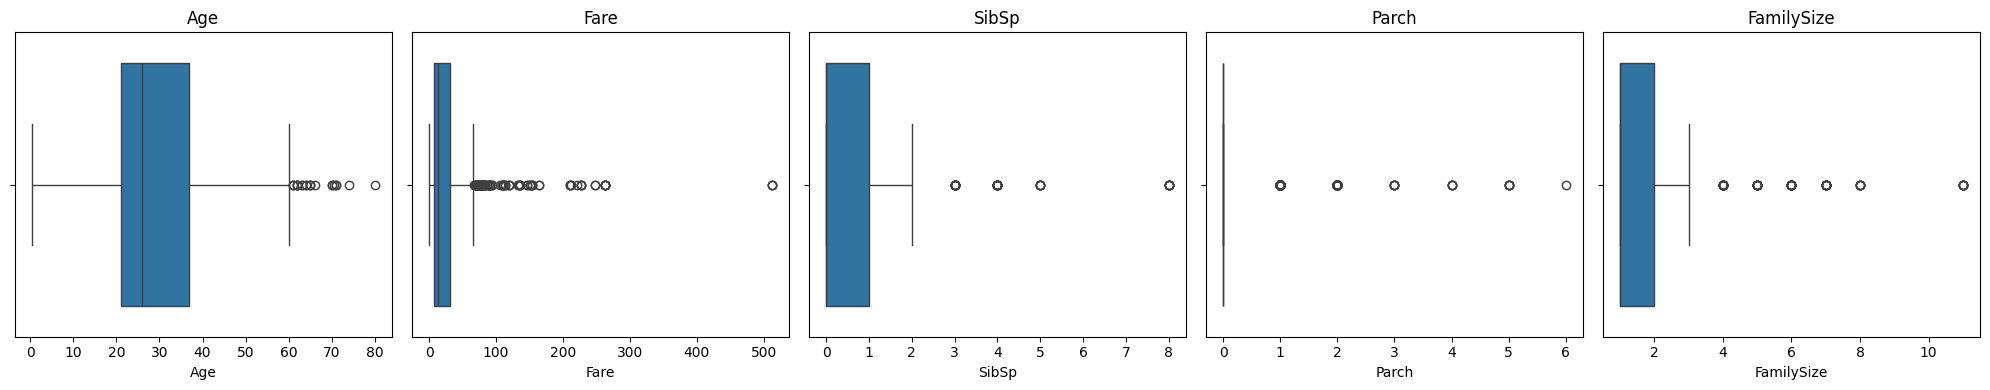

In [14]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
for col in numeric_cols:
    print(f"{col}: {count_outliers_iqr(titanic_df[col])} outlierów (IQR)")

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4*len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=titanic_df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Age ma pojedyncze wartości powyżej ok. 60 lat — realistyczne, zostają. Fare ma sporo wartości poza typowym zakresem (silny prawy skos). SibSp/Parch/FamilySize IQR oznacza jako mające mnóstwo "outlierów" — to artefakt metody: te zmienne mają rozkład silnie skupiony w 0 (Q1=Q3=0), więc IQR≈0 i niemal każda niezerowa wartość wypada poza granicę. To nie błędne dane, tylko rzadsze, prawdziwe przypadki (liczne rodziny) — lepiej ocenić je przez rozkład częstości niż formalny test IQR.

In [18]:
titanic_df['Fare_log'] = np.log1p(titanic_df['Fare'])
titanic_df[['Fare', 'Fare_log']].describe()

,Fare,Fare_log
count,891.000000,891.000000
mean,31.756069,2.951859
std,49.325538,0.958760
min,0.000000,0.000000
25%,8.050000,2.202765
50%,14.000000,2.708050
75%,31.275000,3.474293
max,512.329200,6.240917


Dla cech kategorialnych "skrajność" oznacza w praktyce bardzo rzadkie kategorie — sprawdzamy więc rozkład częstości, żeby wychwycić grupy, które mogłyby zaburzać model (zbyt mało obserwacji) albo sugerować błąd w danych.

In [19]:
categorical_check_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'IsAlone', 'HasCabin']
for col in categorical_check_cols:
    print(titanic_df[col].value_counts(normalize=True).round(3))
    print()

Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

Sex
male      0.648
female    0.352
Name: proportion, dtype: float64

Embarked
S    0.725
C    0.189
Q    0.086
Name: proportion, dtype: float64

Title
Mr        0.580
Miss      0.208
Mrs       0.141
Master    0.045
Rare      0.026
Name: proportion, dtype: float64

Deck
U    0.771
C    0.066
B    0.053
D    0.037
E    0.036
A    0.017
F    0.015
G    0.004
T    0.001
Name: proportion, dtype: float64

IsAlone
1    0.603
0    0.397
Name: proportion, dtype: float64

HasCabin
0    0.771
1    0.229
Name: proportion, dtype: float64



Embarked=Q to najmniejsza grupa portów (ok. 9% pasażerów), a Deck=T to zaledwie pojedynczy pasażer.

Kodowanie robimy na kopii zbioru (`titanic_encoded`), żeby zachować czytelne etykiety (`male`/`female` itd.) w `titanic_df` na potrzeby wcześniejszych i dalszych wizualizacji.

In [20]:
titanic_encoded = titanic_df.copy()
titanic_encoded['Sex'] = titanic_encoded['Sex'].map({'male': 0, 'female': 1})

titanic_encoded = pd.get_dummies(
    titanic_encoded,
    columns=['Embarked', 'Title', 'Deck'],
    drop_first=True
)

print('Kształt zbioru po kodowaniu:', titanic_encoded.shape)
print('Liczba brakujących wartości:', titanic_encoded.isna().sum().sum())
titanic_encoded.head()

Kształt zbioru po kodowaniu: (891, 25)
Liczba brakujących wartości: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,...,False,False,False,False,False,False,False,False,False,True
2,1,1,1,38.0,1,0,71.2833,2,0,1,...,True,False,False,True,False,False,False,False,False,False
3,1,3,1,26.0,0,0,7.9250,1,1,0,...,False,False,False,False,False,False,False,False,False,True
4,1,1,1,35.0,1,0,53.1000,2,0,1,...,True,False,False,True,False,False,False,False,False,False
5,0,3,0,35.0,0,0,8.0500,1,1,0,...,False,False,False,False,False,False,False,False,False,True


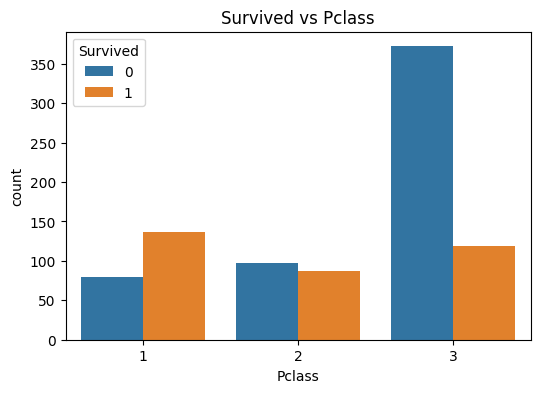

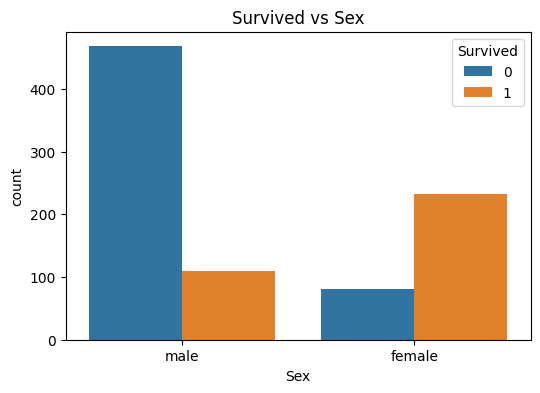

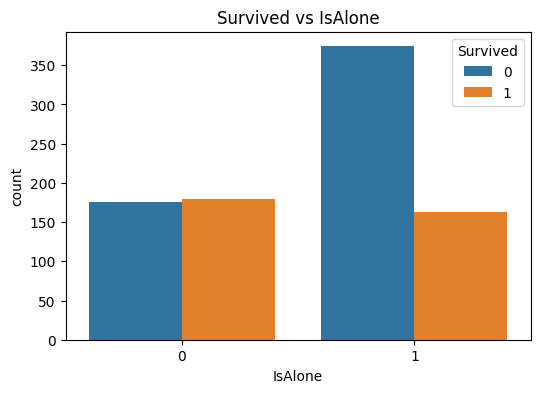

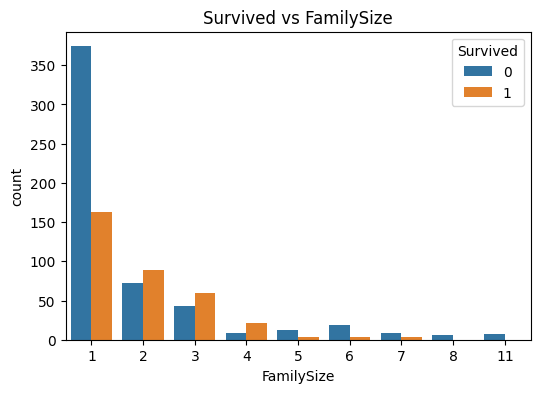

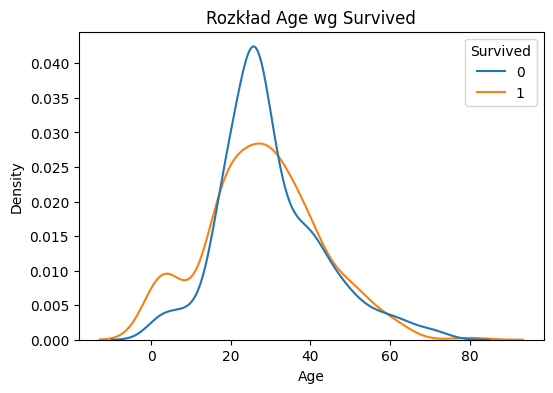

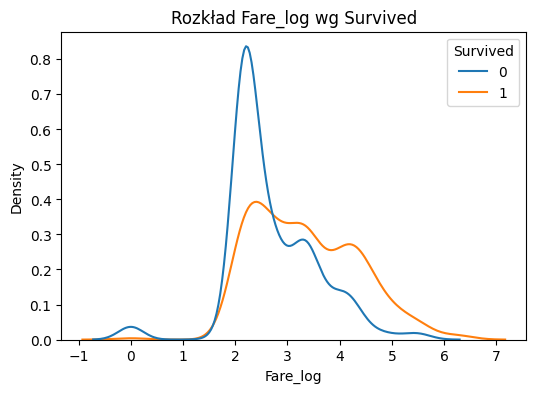

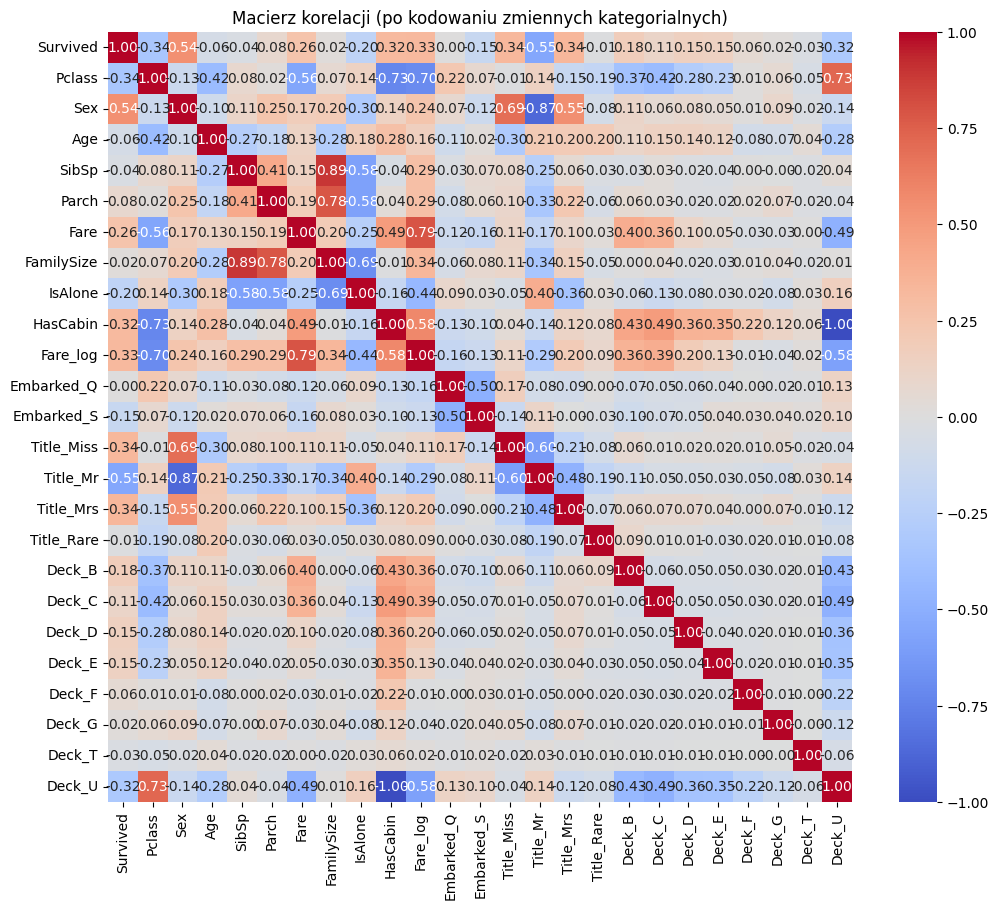

In [21]:
for col in ['Pclass', 'Sex', 'IsAlone', 'FamilySize']:
    plot_categorical_vs_survived(titanic_df, col)

for col in ['Age', 'Fare_log']:
    plot_numeric_by_survived(titanic_df, col)

plt.figure(figsize=(12, 10))
sns.heatmap(titanic_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Macierz korelacji (po kodowaniu zmiennych kategorialnych)')
plt.show()

Z tego co widać:
*   Pasażerowie I klasy przeżywali najczęściej,
*   Mężczyźni dużo częściej nieprzeżywali niż kobiety,
*   Osoby które były same 2 razy częściej nieprzeżywały,
*   Osoby podróżujące z rodziną miały wyrównane szanse

Macierz korelacji potwierdza te obserwacje liczbowo: zakodowana płeć oraz tytuły grzecznościowe mają najsilniejszy związek z `Survived`, zaraz obok `Pclass` (korelacja ujemna — im wyższa liczba klasy, tym niżej pasażer był umiejscowiony i tym mniejsze szanse na przeżycie) oraz `Fare`/`Fare_log` (korelacja dodatnia, w dużej mierze pochodna klasy podróży).